In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.types import Tensor

import darksun as ds
from darksun.show import DSPlot

ds.show.set_figures_darkbkg()

In [61]:
def model(x: Tensor, a: float = 0.01, b: float = 4.0) -> Tensor:
    """Generate data through custom model."""
    y = a * torch.square(x) * torch.exp(b * x)
    return y / y.max()

def polyfit(x: Tensor, y: Tensor, degree: int) -> Tensor:
    """Performs a polynomial fit of the given data."""
    X = x.unsqueeze(1) ** torch.arange(0, degree + 1)
    coeffs = torch.linalg.lstsq(X, y).solution
    return coeffs

def eval_fit(x: Tensor, coeffs: Tensor) -> Tensor:
    """Evaluates the data as polynomial with given coeffs."""
    X = x.unsqueeze(1) ** torch.arange(0, len(coeffs))
    Y = X @ coeffs
    return Y


# hyperparams
n: int = 20
sigma: float = 1e-1
degree: int = 15
# data
x = torch.linspace(0, 1, n)
true = model(x)
obs = true + torch.normal(torch.zeros_like(x), sigma * torch.ones_like(x))
# perform lstsq fit
alpha = polyfit(x, obs, degree)
x_ = torch.linspace(0, 1, 1000)
pred = eval_fit(x_, alpha)

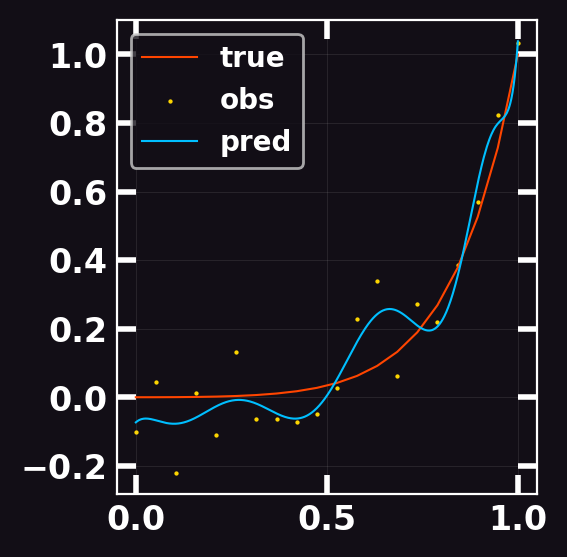

In [62]:
# show results
dsp = DSPlot(1, 1)
fig, ax = dsp.config_subplots(size=3)
dsp.config_ticks(ax)
ax.plot(x, true, c='OrangeRed', label='true', linewidth=0.75)
ax.scatter(x, obs, c='Gold', label='obs', s=0.3)
ax.plot(x_, pred, c='DeepSkyBlue', label='pred', linewidth=0.75)
ax.grid(True, alpha=0.2)
ax.legend(loc='best')
plt.show()

In [33]:
true, obs, pred, torch.sqrt(torch.mean(torch.square(obs - pred)))

alpha

tensor([ 3.0817e-01, -1.1271e+01,  9.0467e+01, -2.8616e+02,  3.5341e+02,
         1.2368e-01, -2.6971e+02, -2.4625e+01,  2.6106e+02, -1.1189e+02])